# Purchase Prediction From Ads: Logistic Regression


In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
raw_data = pd.read_csv("data/Social_Network_Ads.csv")

In [3]:
raw_data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
raw_data.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
# check for duplicate rows
raw_data.duplicated().sum()

np.int64(0)

In [8]:
# converting the "Gender" col to numerical values
data = raw_data.copy()
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

In [9]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [10]:
data.describe()

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,1.569154e+07,0.490000,37.655000,69742.500000,0.357500
std,7.165832e+04,0.500526,10.482877,34096.960282,0.479864
min,1.556669e+07,0.000000,18.000000,15000.000000,0.000000
25%,1.562676e+07,0.000000,29.750000,43000.000000,0.000000
50%,1.569434e+07,0.000000,37.000000,70000.000000,0.000000
75%,1.575036e+07,1.000000,46.000000,88000.000000,1.000000
max,1.581524e+07,1.000000,60.000000,150000.000000,1.000000


In [11]:
# checking the distribution of the target variable "Purchased"
data["Purchased"].value_counts(normalize=True)

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64

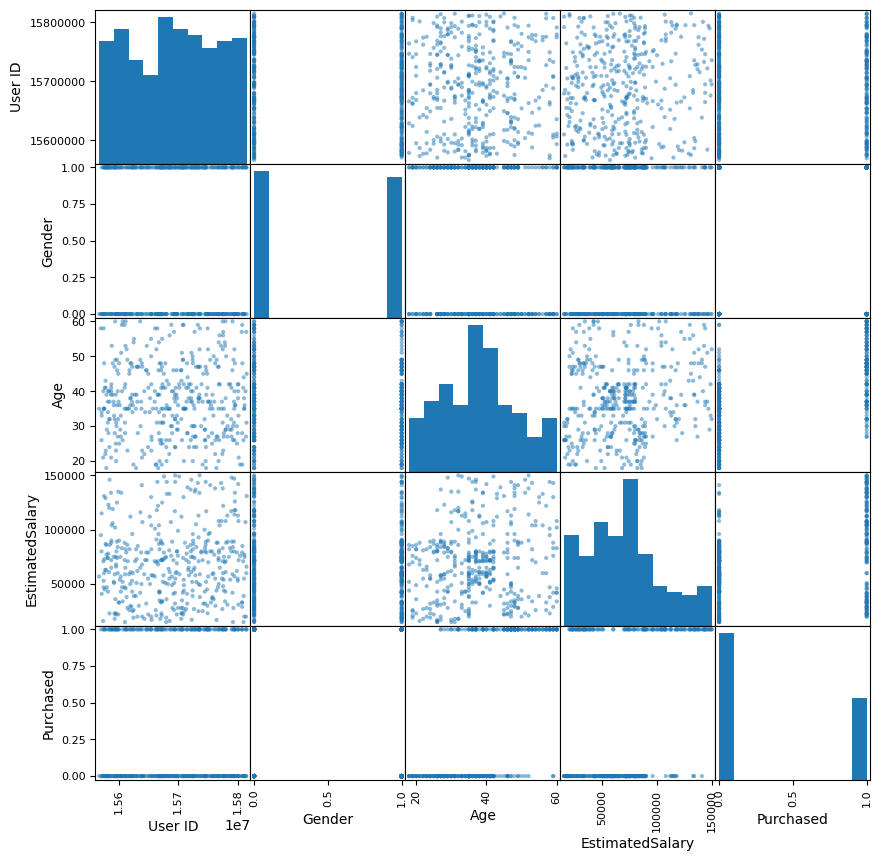

In [12]:
numeric_data = data.select_dtypes(include=["float64", "int64"])
scatter_matrix(numeric_data, alpha=0.5, figsize=(10, 10), diagonal="hist")
plt.show()

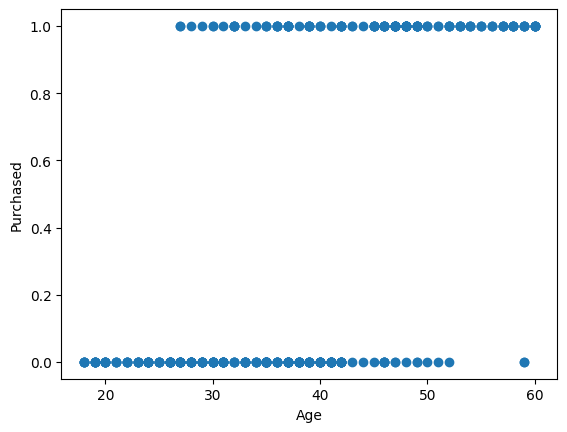

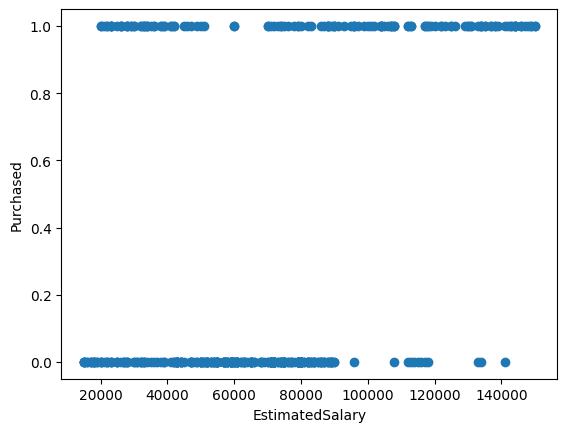

In [17]:
features = data[["Age", "EstimatedSalary"]]
for i in features:
    plt.scatter(data[i], data["Purchased"])
    plt.xlabel(f"{i}")
    plt.ylabel("Purchased")
    plt.show()

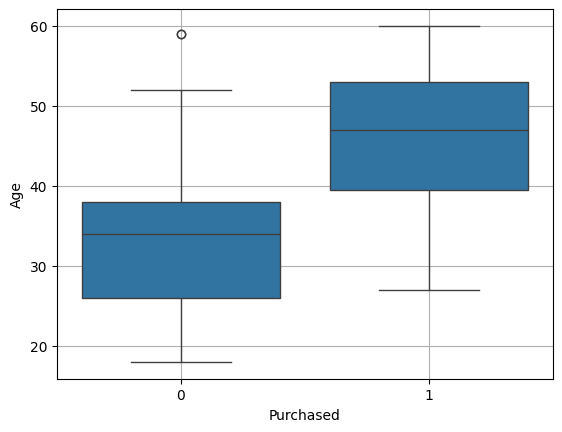

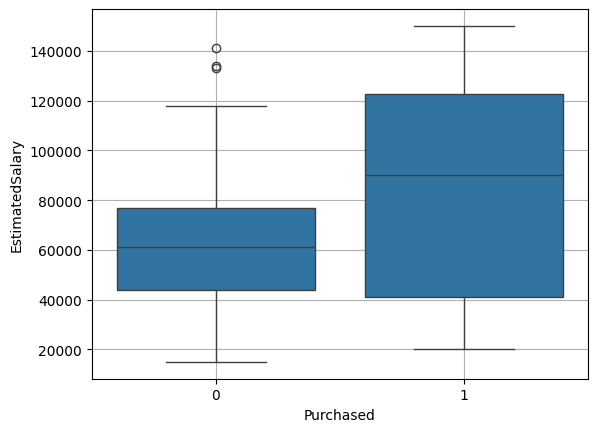

In [ ]:
# for i in features:
#     data_0 = data[data["Purchased"] == 0][i]
#     data_1 = data[data["Purchased"] == 1][i]

#     plt.boxplot([data_0, data_1])
#     plt.title(f"{i} vs Purchased")
#     plt.ylabel(i)
#     plt.grid(True)
#     plt.show()

import seaborn as sns

for i in features:
    sns.boxplot(x=data["Purchased"], y=data[i])
    plt.grid(True)
    plt.show()

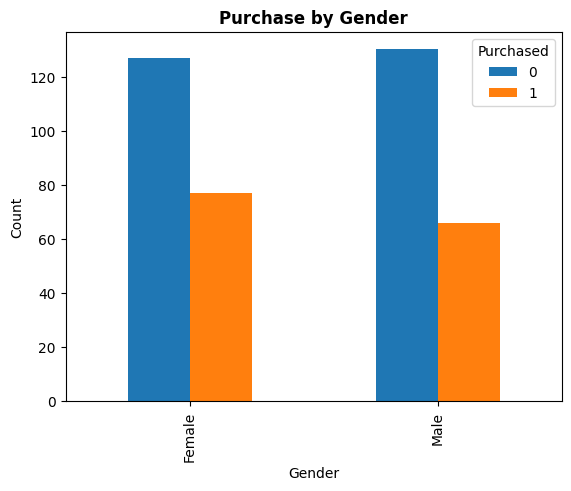

In [24]:
crosstab = pd.crosstab(data["Gender"], data["Purchased"])
crosstab.plot(kind="bar", ax=plt.gca())
plt.title("Purchase by Gender", fontsize=12, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Purchased")
plt.xticks(ticks=range(len(crosstab.index)), labels=["Female", "Male"])
plt.show()

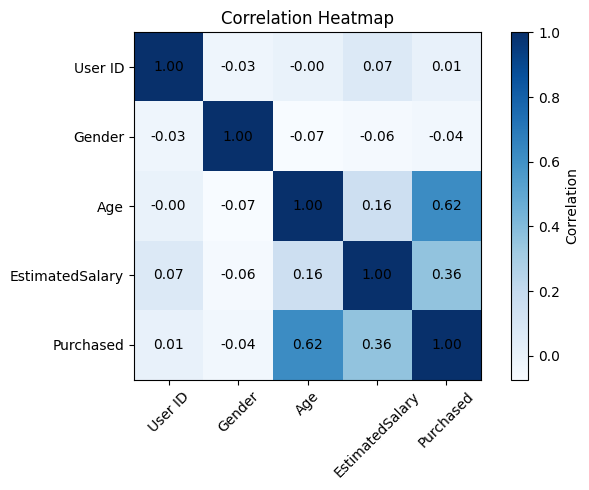

In [ ]:
plt.figure(figsize=(7, 5))
corr = data.corr(numeric_only=True)

plt.imshow(corr, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

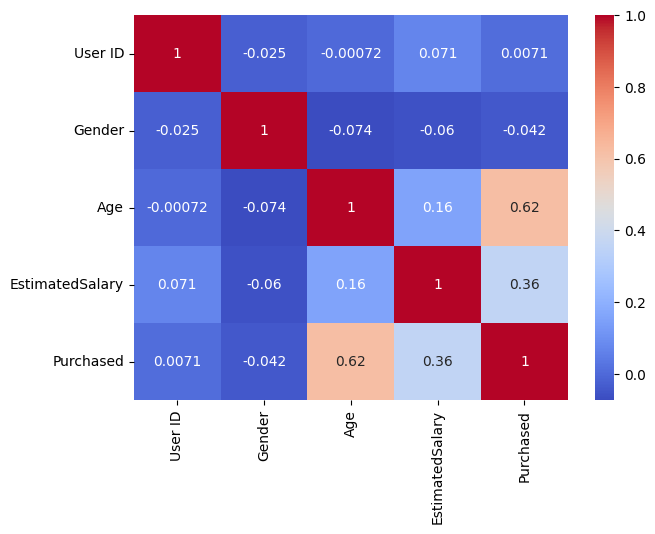

In [28]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

- **Correlation values range from -1 to +1:**
  - +1 -> Perfect positive correlation (which one increases, the other always increases) (kinda Directly proportional)
  - 0 -> No correlation (variables are independent)
  - -1 Perfect negative correlaton (which one increases, the other always decreases) (kinda Inversely proportional)


In [32]:
# compute the spearman correlation matrix for the dataset
data.corr(method="spearman")

,User ID,Gender,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.026809,-0.002494,0.066768,0.006980
Gender,-0.026809,1.000000,-0.068020,-0.043704,-0.042469
Age,-0.002494,-0.068020,1.000000,0.124824,0.612323
EstimatedSalary,0.066768,-0.043704,0.124824,1.000000,0.306858
Purchased,0.006980,-0.042469,0.612323,0.306858,1.000000


In [33]:
# define X and y features
X = data[["Age", "EstimatedSalary"]]
y = data["Purchased"]

In [34]:
# scaling the features
scaler = StandardScaler()
scaler.fit(X)
x_scaled = scaler.transform(X)

### Train Test Split


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(x_train, y_train)

y_hat_train = model.predict(x_train)

In [36]:
# computing the accuracy of the training dataset
accuracy_train = accuracy_score(y_train, y_hat_train)
print(accuracy_train)

0.840625


In [37]:
# creating a confusion matrix for the training predictions
conf_matrix = pd.DataFrame(
    confusion_matrix(y_train, y_hat_train),
    columns=["Prediction 0", "Prediction 1"],
    index=["Actual 0", "Actual 1"],
)
print(conf_matrix)

          Prediction 0  Prediction 1
Actual 0           190            15
Actual 1            36            79


| N           | Prediction: No | Prediction: Yes |
| ----------- | -------------- | --------------- |
| Actual: No  | TN             | FP              |
| Actual: Yes | FN             | TP              |


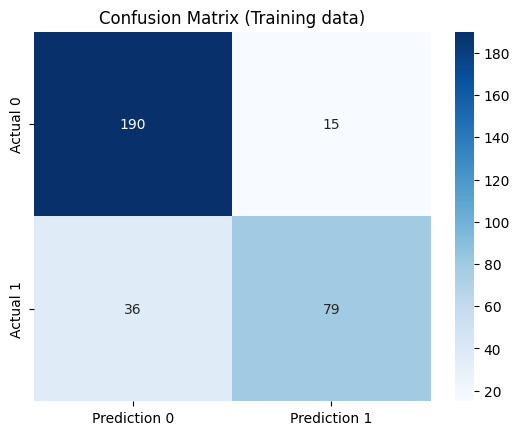

In [43]:
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Training data)")
plt.show()

In [44]:
# printing a detailed classification report for the training prediction
print(classification_report(y_train, y_hat_train))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       205
           1       0.84      0.69      0.76       115

    accuracy                           0.84       320
   macro avg       0.84      0.81      0.82       320
weighted avg       0.84      0.84      0.84       320



In [45]:
# make prediction on the test set and compute accuracy
y_hat_test = model.predict(x_test)
accuracy_test = accuracy_score(y_test, y_hat_test)
print(accuracy_test)

0.8625


In [46]:
conf_matrix_test = pd.DataFrame(
    confusion_matrix(y_test, y_hat_test),
    columns=["Perdicted 0", "Predicted 1"],
    index=["Actual 0", "Actual 1"],
)
print(conf_matrix_test)

          Perdicted 0  Predicted 1
Actual 0           50            2
Actual 1            9           19


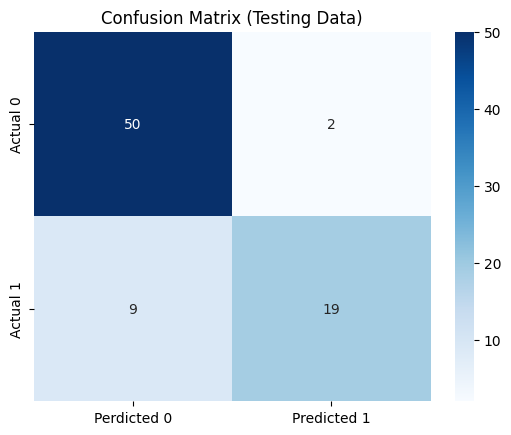

In [47]:
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Testing Data)")
plt.show()

In [48]:
print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



Although the Logistic Regression model achieves good accuracy on both the training and test sets, it is important to check the linearity of the relationship between the numerical features and the log-odds of the target variable


### Create income bins and compute log-odds for each bin


In [50]:
data["IncomeBin"] = pd.qcut(data["EstimatedSalary"], q=8)

bin_mean = data.groupby("IncomeBin", observed=True)[["EstimatedSalary"]].mean()

bin_target = data.groupby("IncomeBin", observed=True)[["Purchased"]].mean()

log_odds = np.log(bin_target / (1 - bin_target))
# observed=True is just a safety check

1. Binning the salary into quantiles

- `pd.qcut(..., q=8)` splits the `EstimatedSalary` column into **8 bins (quantiles)**, each containing roughly the same number of the data points.
- Example: if salaries go from 15,000 to 150,000, it will create 8 bins (like 15k - 30k, 30k - 35k, ..., etc).
- The new column `IncomeBin` stores which bin each row belongs to.
- This helps analyze the relationship between income ranges and purchase probability.

2. Mean salary in each bin

- Groups the data by income bin.
- For each bin, it calculates the mean salary.
- This gives the representative "average salary" per bin.

3. Purchase rate in each bin

- Groups the data by the same bins.
- Takes the mean of Purchased (0/1) in each bin.
- Since Purchased in binary:
  - Mean = proportion of `1`s in that bin = **probability of purchase**.

4. Log-odds of purchase

- Converts probability of purchase into log-odds, which is what logistic regression models internally.
- Formula:
  - `log-odds = ln(p / (1 - p))`
- where p is the purchase probability of that bin
- If purchase rate = 0.25 → log-odds = log(0.25 / 0.75) ≈ -1.1
- If purchase rate = 0.80 → log-odds = log(0.8 / 0.2) ≈ 1.39
- Positive log-odds → high chance of purchase, Negative → low chance.


In [53]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,IncomeBin
0,15624510,1,19,19000,0,"(14999.999, 28000.0]"
1,15810944,1,35,20000,0,"(14999.999, 28000.0]"
2,15668575,0,26,43000,0,"(28000.0, 43000.0]"
3,15603246,0,27,57000,0,"(43000.0, 57000.0]"
4,15804002,1,19,76000,0,"(70000.0, 78000.0]"


In [54]:
print(bin_mean)

                      EstimatedSalary
IncomeBin                            
(14999.999, 28000.0]     21941.176471
(28000.0, 43000.0]       36333.333333
(43000.0, 57000.0]       51153.846154
(57000.0, 70000.0]       62510.204082
(70000.0, 78000.0]       73541.666667
(78000.0, 88000.0]       82836.363636
(88000.0, 115125.0]     100681.818182
(115125.0, 150000.0]    133720.000000


In [55]:
print(bin_target)

                      Purchased
IncomeBin                      
(14999.999, 28000.0]   0.313725
(28000.0, 43000.0]     0.450980
(43000.0, 57000.0]     0.115385
(57000.0, 70000.0]     0.081633
(70000.0, 78000.0]     0.166667
(78000.0, 88000.0]     0.200000
(88000.0, 115125.0]    0.704545
(115125.0, 150000.0]   0.880000


In [56]:
print(log_odds)

                      Purchased
IncomeBin                      
(14999.999, 28000.0]  -0.782759
(28000.0, 43000.0]    -0.196710
(43000.0, 57000.0]    -2.036882
(57000.0, 70000.0]    -2.420368
(70000.0, 78000.0]    -1.609438
(78000.0, 88000.0]    -1.386294
(88000.0, 115125.0]    0.869038
(115125.0, 150000.0]   1.992430


this is super useful for visualizing how purchase likelihood changes with salary (like "high income → more likely to purchase").


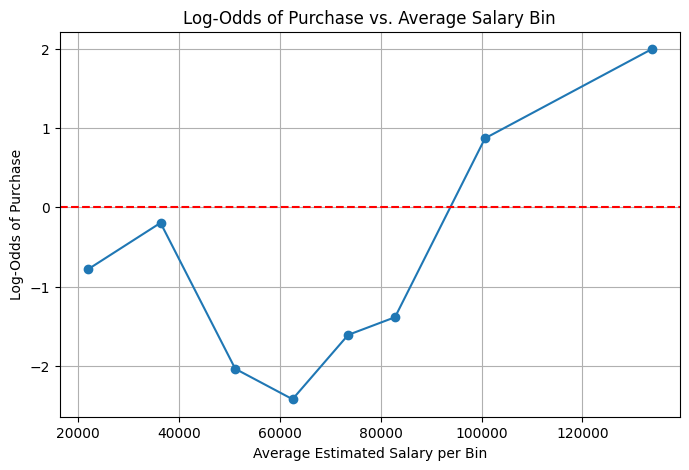

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(bin_mean["EstimatedSalary"], log_odds["Purchased"], marker="o", linestyle="-")
plt.xlabel("Average Estimated Salary per Bin")
plt.ylabel("Log-Odds of Purchase")
plt.title("Log-Odds of Purchase vs. Average Salary Bin")
plt.grid(True)

# horizontal line at 0 log-odds (p=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.show()

Upon plotting the log-odds of purchasing against the binned mean of EstimatedSalary(income), it is evident that the relationship is not linear.


### Encoding the binned income as ordinal values


In [58]:
ord = OrdinalEncoder()
data["IncomeBin"] = ord.fit_transform(data[["IncomeBin"]])

### One-hot encode the binned income feature


In [59]:
one_hot = OneHotEncoder()
enc = one_hot.fit_transform(data[["IncomeBin"]])
data[one_hot.categories_[0]] = enc.toarray()

In [60]:
# define X and y after one-hot encoding income bins
X = data.drop(["User ID", "Gender", "EstimatedSalary", "Purchased"], axis=1)
y = data["Purchased"]

In [61]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,IncomeBin,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
0,15624510,1,19,19000,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15810944,1,35,20000,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,15668575,0,26,43000,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,15603246,0,27,57000,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,15804002,1,19,76000,0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


1. Oridinal Encoding

- `IncomeBin` column originally contains interval labels like `(15000, 30000]`, etc.
- ML models don't understand text/intervals → they need numbers.
- `OridinalEncoder` coverts each bin into a number `(0, 1, 2, 3, 4, 5, 6, 7)`.
- Problem: Ordinal encoding imposes an order (0 < 1 < 2 …). That’s fine for bins because they do have order (lower salary < higher salary). But sometimes, you don’t want ML to assume that "bin 2" is exactly twice "bin 1".

2. One-Hot Encoding

- Instead of giving a single number for the bin, we create separate columns for each bin.
- Example:
  - | 0.0 | 0.1 | ... | 0.7 |
    | --- | --- | --- | --- |
    | 1   | 0   | ... | 0   |
    | 0   | 1   | ... | 0   |
    | 0   | 0   | ... | 1   |
- Only one column is 1 at a time, representing which bin the record belongs to.
- `enc.toarray()` converts the encoded sparse matrix into a full NumPy array.
- `one_hot.categories-[0]` gives the bin categories (like `[0.0, 1.0, ..., 7.0]`) which are then used as column names.
- Benefit: The models can now treat each salary bin independently, without assuming order.

3. Defining features (X) and target (y)

- X (features) = all useful predictors.
  - Dropping:
    - `User ID`, `Gender`, etc.
- y (target) = `Purchased` (whether user bought or not).


In [62]:
# split the dataset, train log_reg with one_hot encoded income, and evaluate training accuracy
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

model = LogisticRegression()
model.fit(x_train, y_train)

y_hat_train = model.predict(x_train)

accuracy_train = accuracy_score(y_train, y_hat_train)
print(accuracy_train)

0.9


In [63]:
conf_matrix_train = pd.DataFrame(
    confusion_matrix(y_train, y_hat_train),
    columns=["Prediction 0", "Prediction 1"],
    index=["Actual 0", "Actual 1"],
)
print(conf_matrix_train)

          Prediction 0  Prediction 1
Actual 0           189            16
Actual 1            16            99


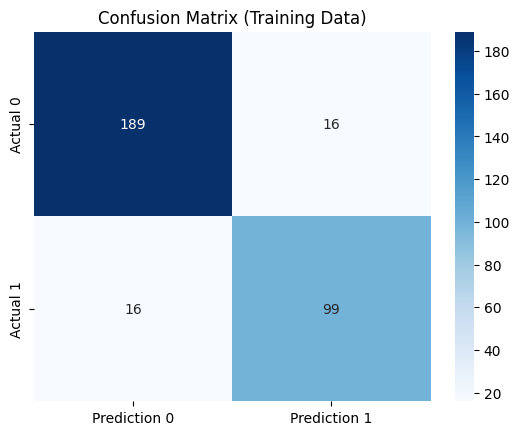

In [64]:
sns.heatmap(conf_matrix_train, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Training Data)")
plt.show()

In [65]:
print(classification_report(y_train, y_hat_train))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       205
           1       0.86      0.86      0.86       115

    accuracy                           0.90       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.90      0.90      0.90       320



In [66]:
# make predictions on the test set and compute test accuracy
y_hat_test = model.predict(x_test)
accuracy_test = accuracy_score(y_test, y_hat_test)
print(accuracy_test)

0.95


In [67]:
conf_matrix_test = pd.DataFrame(
    confusion_matrix(y_test, y_hat_test),
    columns=["Predicted 0", "Predicted 1"],
    index=["Actual 0", "Actual 1"],
)
print(conf_matrix_test)

          Predicted 0  Predicted 1
Actual 0           50            2
Actual 1            2           26


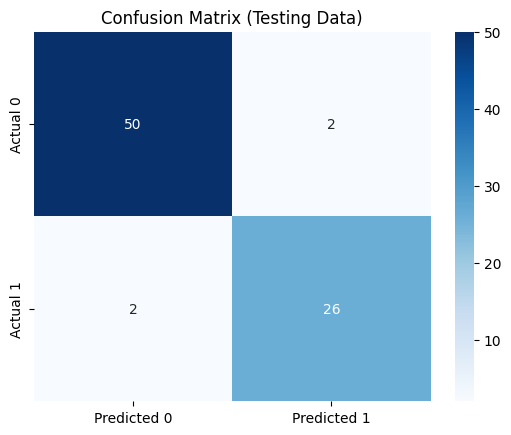

In [68]:
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Testing Data)")
plt.show()

In [69]:
print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        52
           1       0.93      0.93      0.93        28

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



We applied Logistic Regression to predict purchases based on age and estimated salary. By binning and one-hot encoding income, we addressed the non-linear relationship with the target. The model significantly improved accuracy on both training and test sets.